In [1]:
import os
import csv
import json
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
os.makedirs("./artifacts/figures", exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

RANDOM_SEED = 42
seed_everything(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
df = pd.read_csv("./data/S12-hw-dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер: {df.shape}")
print(f"Диапазон: {df['date'].min()} - {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

Размер: (4320, 2)
Диапазон: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


In [4]:
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [5]:
df.describe()

,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB


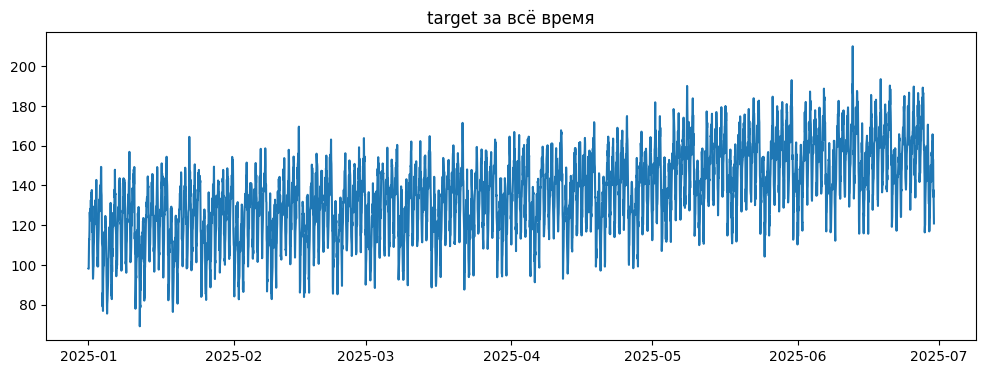

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['target'])
plt.title("target за всё время")
plt.show()

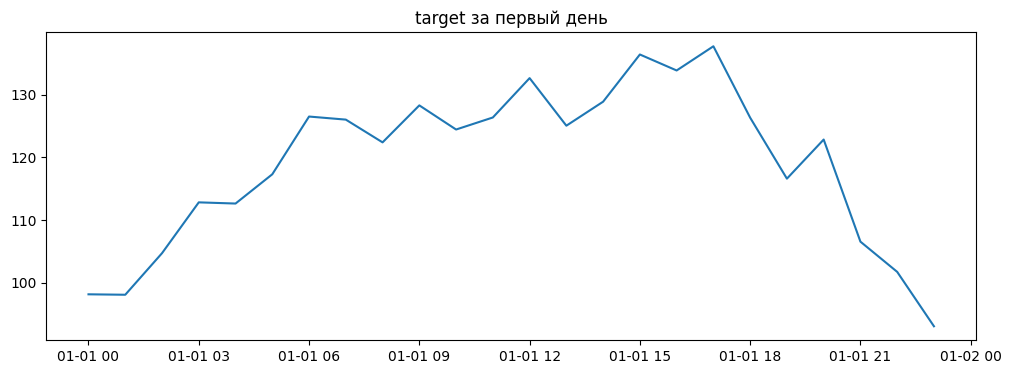

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:24, :]['date'], df.iloc[:24, :]['target'])
plt.title("target за первый день")
plt.show()

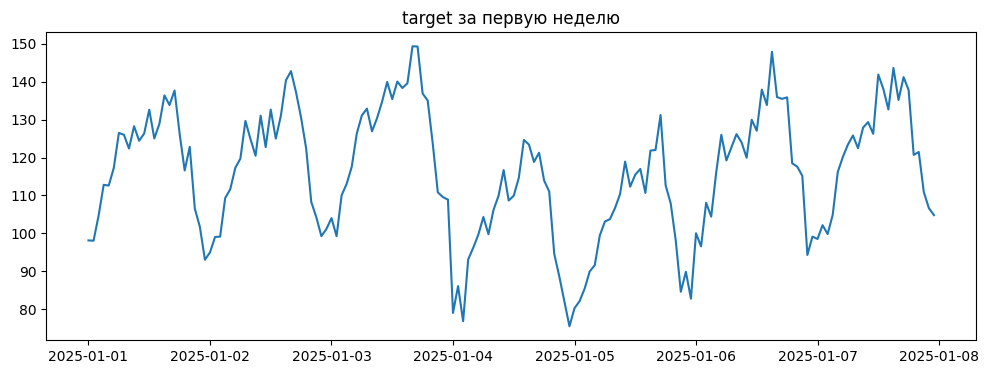

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:24*7, :]['date'], df.iloc[:24*7, :]['target'])
plt.title("target за первую неделю")
plt.show()

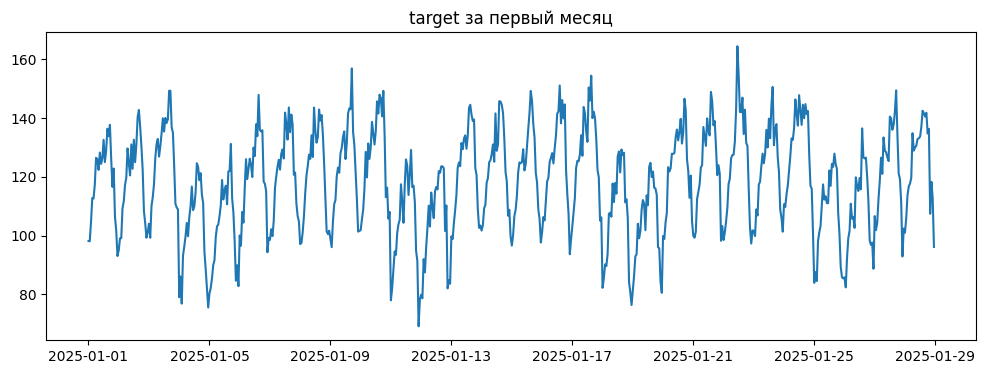

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:24*7*4, :]['date'], df.iloc[:24*7*4, :]['target'])
plt.title("target за первый месяц")
plt.show()

In [11]:
def add_features(data):
    """
    Создание признаков для датасета
    """
    df_f = data.copy()

    for l in [1, 7, 14]:
        df_f[f'lag_{l}'] = df_f['target'].shift(l)
    
    df_f['rolling_mean_7'] = df_f['target'].shift(1).rolling(7).mean()
    df_f['rolling_std_7'] = df_f['target'].shift(1).rolling(7).std()
    
    df_f['dayofweek'] = df_f['date'].dt.dayofweek
    df_f['hour'] = df_f['date'].dt.hour
    return df_f.dropna()

df = add_features(df)
df.head()

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour
14,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,14
15,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,15
16,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,16
17,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,17
18,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,18


В датасете лежат данные в виде временного ряда за первое полугодие 2025 года (с 1 января по 29 июня включительно). Замер целевой переменной `target` происходил каждый час. Есть слабый ростущий тренд + сильно выраженная сезонность внутри дня (поднимается в пик днеём и падает ночью) и внутринедельная (по выходным заметно ниже). 
Пропусков нет

Для временных рядов случайное перемешивание данных (`random split`) некорректно, так как нарушает временную зависимость наблюдений. При `random split` будущие значения могут попасть в обучающую выборку, а прошлые — в тестовую, что приводит к "утечке будущего" и создает иллюзию высокого качества модели. В реальном прогнозировании мы всегда предсказываем будущее на основе прошлого, поэтому единственно правильный подход — `temporal split`, сохраняющий хронологический порядок. В данной работе используется разбиение: 70% — обучение, 15% — валидация, 15% — тест, строго во временной последовательности.

In [12]:
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

target_col = "target"
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'hour']

In [13]:
train = df.iloc[:train_end].copy()
X_train, y_train = train[feature_cols], train[target_col]
train.head()

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour
14,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,14
15,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,15
16,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,16
17,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,17
18,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,18


In [14]:
val = df.iloc[train_end:val_end].copy()
X_val, y_val = val[feature_cols], val[target_col]
val.head()

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour
3028,2025-05-07 04:00:00,143.93,141.57,137.35,166.58,133.027143,6.035028,2,4
3029,2025-05-07 05:00:00,150.34,143.93,131.33,176.40,133.967143,7.217217,2,5
3030,2025-05-07 06:00:00,145.68,150.34,133.29,163.32,136.682857,9.327554,2,6
3031,2025-05-07 07:00:00,153.64,145.68,122.76,153.98,138.452857,9.742744,2,7
3032,2025-05-07 08:00:00,159.18,153.64,129.46,160.61,142.864286,8.343510,2,8


In [15]:
test = df.iloc[val_end:].copy()
X_test, y_test = test[feature_cols], test[target_col]
test.head()

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour
3674,2025-06-03 02:00:00,139.80,138.51,163.79,166.80,144.625714,10.946865,1,2
3675,2025-06-03 03:00:00,145.54,139.80,151.97,168.15,141.198571,6.985744,1,3
3676,2025-06-03 04:00:00,150.98,145.54,146.55,176.55,140.280000,5.623190,1,4
3677,2025-06-03 05:00:00,154.94,150.98,143.72,177.95,140.912857,6.609276,1,5
3678,2025-06-03 06:00:00,162.64,154.94,137.57,182.07,142.515714,8.495016,1,6


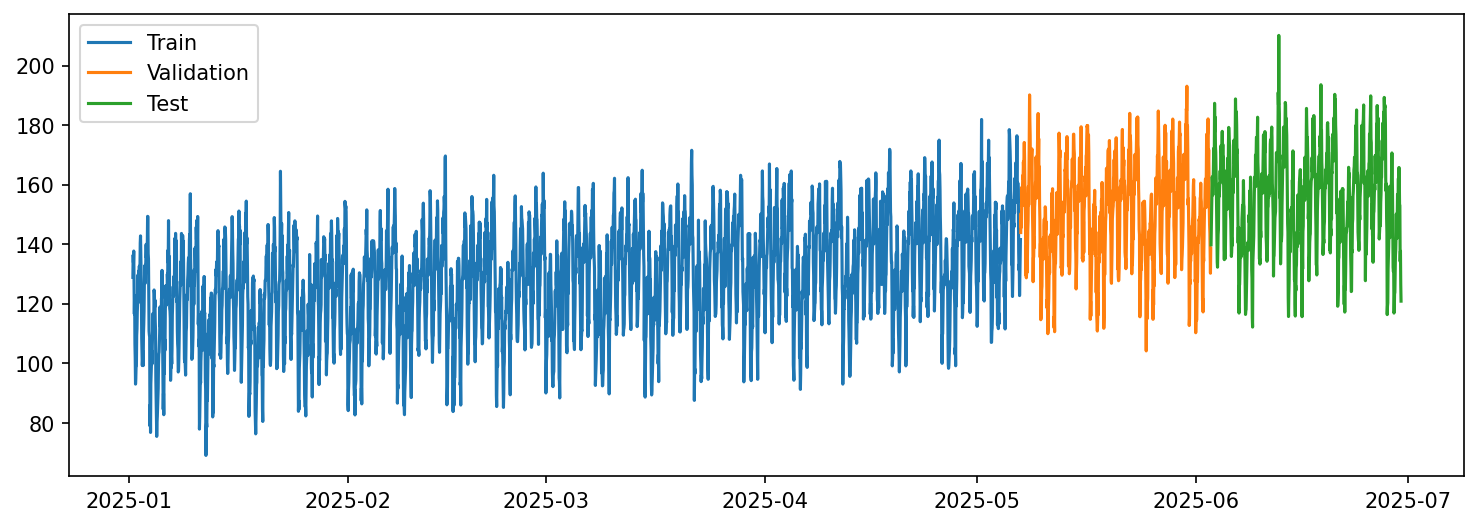

In [16]:
plt.figure(figsize=(12, 4), dpi=150)
plt.plot(train['date'], train['target'], label='Train')
plt.plot(val['date'], val['target'], label='Validation')
plt.plot(test['date'], test['target'], label='Test')
plt.legend()
plt.savefig('artifacts/figures/series_split.png')
plt.show()

# Построение baseline-ов

In [17]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

In [18]:
# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val["lag_1"].to_numpy()
test_pred_naive = test["lag_1"].to_numpy()

In [19]:
# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val["rolling_mean_7"].to_numpy()
test_pred_ma7 = test["rolling_mean_7"].to_numpy()

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Ridge 
ridge = Ridge(alpha=1.0, random_state=RANDOM_SEED)
ridge.fit(X_train_scaled, y_train)
val_pred_ridge = ridge.predict(X_val_scaled)

In [22]:
baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
    evaluate_regression(y_val, val_pred_ridge, "Ridge + StandartScaler"),
], ignore_index=True)

baseline_results_val

,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594
1,MovingAverage(7),12.723717,15.236326,8.828779
2,Ridge + StandartScaler,6.363002,7.888101,4.281074


# Реализация GRU

In [23]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size
    
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor([y])

In [24]:
window_size = 24  # 24 часа (сутки)
hidden_size = 64
num_layers = 2
learning_rate = 0.001
n_epochs = 50
batch_size = 64

train_target = train['target'].values
val_target = val['target'].values
test_target = test['target'].values

target_scaler = StandardScaler()
train_target_scaled = target_scaler.fit_transform(train_target.reshape(-1, 1)).flatten()
val_target_scaled = target_scaler.transform(val_target.reshape(-1, 1)).flatten()
test_target_scaled = target_scaler.transform(test_target.reshape(-1, 1)).flatten()

train_dataset = TimeSeriesDataset(train_target_scaled, window_size)
val_dataset = TimeSeriesDataset(val_target_scaled, window_size)
test_dataset = TimeSeriesDataset(test_target_scaled, window_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Обучающих примеров: {len(train_dataset)}")
print(f"Валидационных примеров: {len(val_dataset)}")
print(f"Тестовых примеров: {len(test_dataset)}")

Обучающих примеров: 2990
Валидационных примеров: 622
Тестовых примеров: 622


In [25]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [26]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate(model, loader, criterion, scaler=None):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item()
            all_preds.extend(output.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
    
    all_preds = np.array(all_preds).flatten()
    all_targets = np.array(all_targets).flatten()
    
    if scaler is not None:
        all_preds_orig = scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
        all_targets_orig = scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()
        return {
            'loss': total_loss / len(loader),
            'mae': mean_absolute_error(all_targets_orig, all_preds_orig),
            'rmse': np.sqrt(mean_squared_error(all_targets_orig, all_preds_orig)),
            'mape': mean_absolute_percentage_error(all_targets_orig, all_preds_orig)
        }
    else:
        return {
            'loss': total_loss / len(loader),
            'mae': mean_absolute_error(all_targets, all_preds),
            'rmse': np.sqrt(mean_squared_error(all_targets, all_preds)),
            'mape': mean_absolute_percentage_error(all_targets, all_preds)
        }

In [27]:
model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [28]:
best_val_mae = float('inf')
train_losses = []
val_losses = []
val_maes = []
val_rmses = []
val_mapes = []

for epoch in range(n_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_metrics = validate(model, val_loader, criterion, scaler=target_scaler)
    
    train_losses.append(train_loss)
    val_losses.append(val_metrics['loss'])
    val_maes.append(val_metrics['mae'])
    val_rmses.append(val_metrics['rmse'])
    val_mapes.append(val_metrics['mape'])
    
    if val_metrics['mae'] < best_val_mae:
        best_val_mae = val_metrics['mae']
        best_val_rmse = val_metrics['rmse']
        best_val_mape = val_metrics['mape']
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
        best_epoch = epoch + 1
    
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:3d}/{n_epochs} | train_loss: {train_loss:.4f} | val_MAE: {val_metrics['mae']:.4f} | val_MAPE: {val_metrics['mape']:.4%}")

epoch  10/50 | train_loss: 0.1438 | val_MAE: 6.0840 | val_MAPE: 4.0832%
epoch  20/50 | train_loss: 0.1009 | val_MAE: 5.4107 | val_MAPE: 3.6376%
epoch  30/50 | train_loss: 0.0962 | val_MAE: 5.2082 | val_MAPE: 3.5174%
epoch  40/50 | train_loss: 0.0937 | val_MAE: 5.1472 | val_MAPE: 3.4811%
epoch  50/50 | train_loss: 0.0917 | val_MAE: 5.1347 | val_MAPE: 3.4742%


In [29]:
experiments_res = pd.concat([
    baseline_results_val,
    pd.DataFrame([{
        'model': 'GRU + StandartScaler', 
        'MAE': best_val_mae,
        'RMSE': best_val_rmse,
        'MAPE_%': best_val_mape  
    }])
], ignore_index=True)
experiments_res

,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594
1,MovingAverage(7),12.723717,15.236326,8.828779
2,Ridge + StandartScaler,6.363002,7.888101,4.281074
3,GRU + StandartScaler,5.134693,6.674498,0.034742


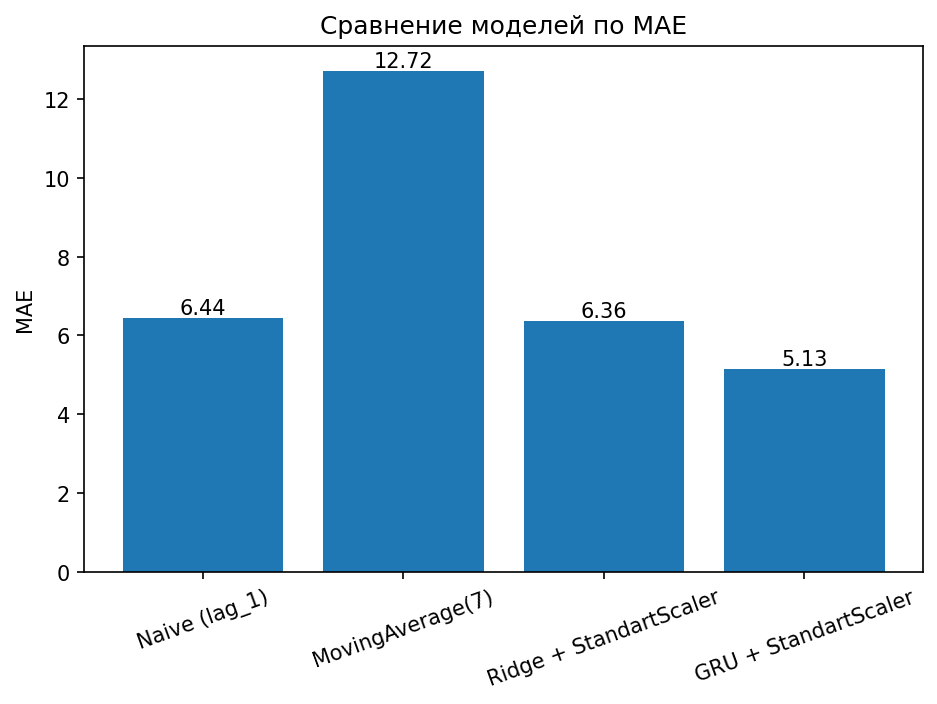

In [30]:
plt.figure(dpi=150)
models = experiments_res['model']
mae = experiments_res['MAE']
plt.bar(models, mae)

for i, v in enumerate(mae):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.title('Сравнение моделей по MAE')
plt.ylabel('MAE')
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()


Результаты на тесте для GRU:
MAE:  5.9605
RMSE: 7.5345
MAPE: 3.8907%


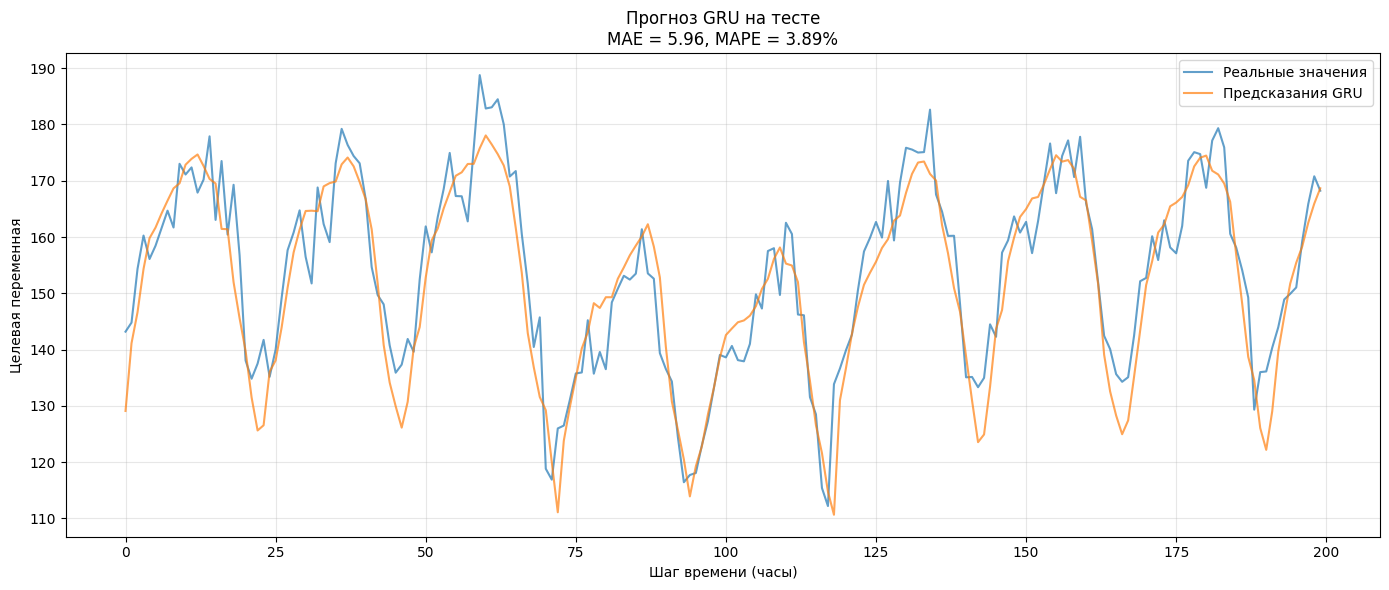

In [31]:
test_metrics = validate(model, test_loader, criterion, scaler=target_scaler)
    
print(f"\nРезультаты на тесте для GRU:")
print(f"MAE:  {test_metrics['mae']:.4f}")
print(f"RMSE: {test_metrics['rmse']:.4f}")
print(f"MAPE: {test_metrics['mape']:.4%}")

model.eval()
all_preds_scaled = []
all_targets_scaled = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = model(x)
        all_preds_scaled.extend(output.cpu().numpy())
        all_targets_scaled.extend(y.numpy())

all_preds_original = target_scaler.inverse_transform(np.array(all_preds_scaled).reshape(-1, 1)).flatten()
all_targets_original = target_scaler.inverse_transform(np.array(all_targets_scaled).reshape(-1, 1)).flatten()

n_points = min(200, len(all_targets_original))
plt.figure(figsize=(14, 6))
plt.plot(all_targets_original[:n_points], label='Реальные значения', alpha=0.7, linewidth=1.5)
plt.plot(all_preds_original[:n_points], label='Предсказания GRU', alpha=0.7, linewidth=1.5)
plt.xlabel('Шаг времени (часы)')
plt.ylabel('Целевая переменная')
plt.legend()
plt.title(f'Прогноз GRU на тесте\nMAE = {test_metrics["mae"]:.2f}, MAPE = {test_metrics["mape"]:.2%}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

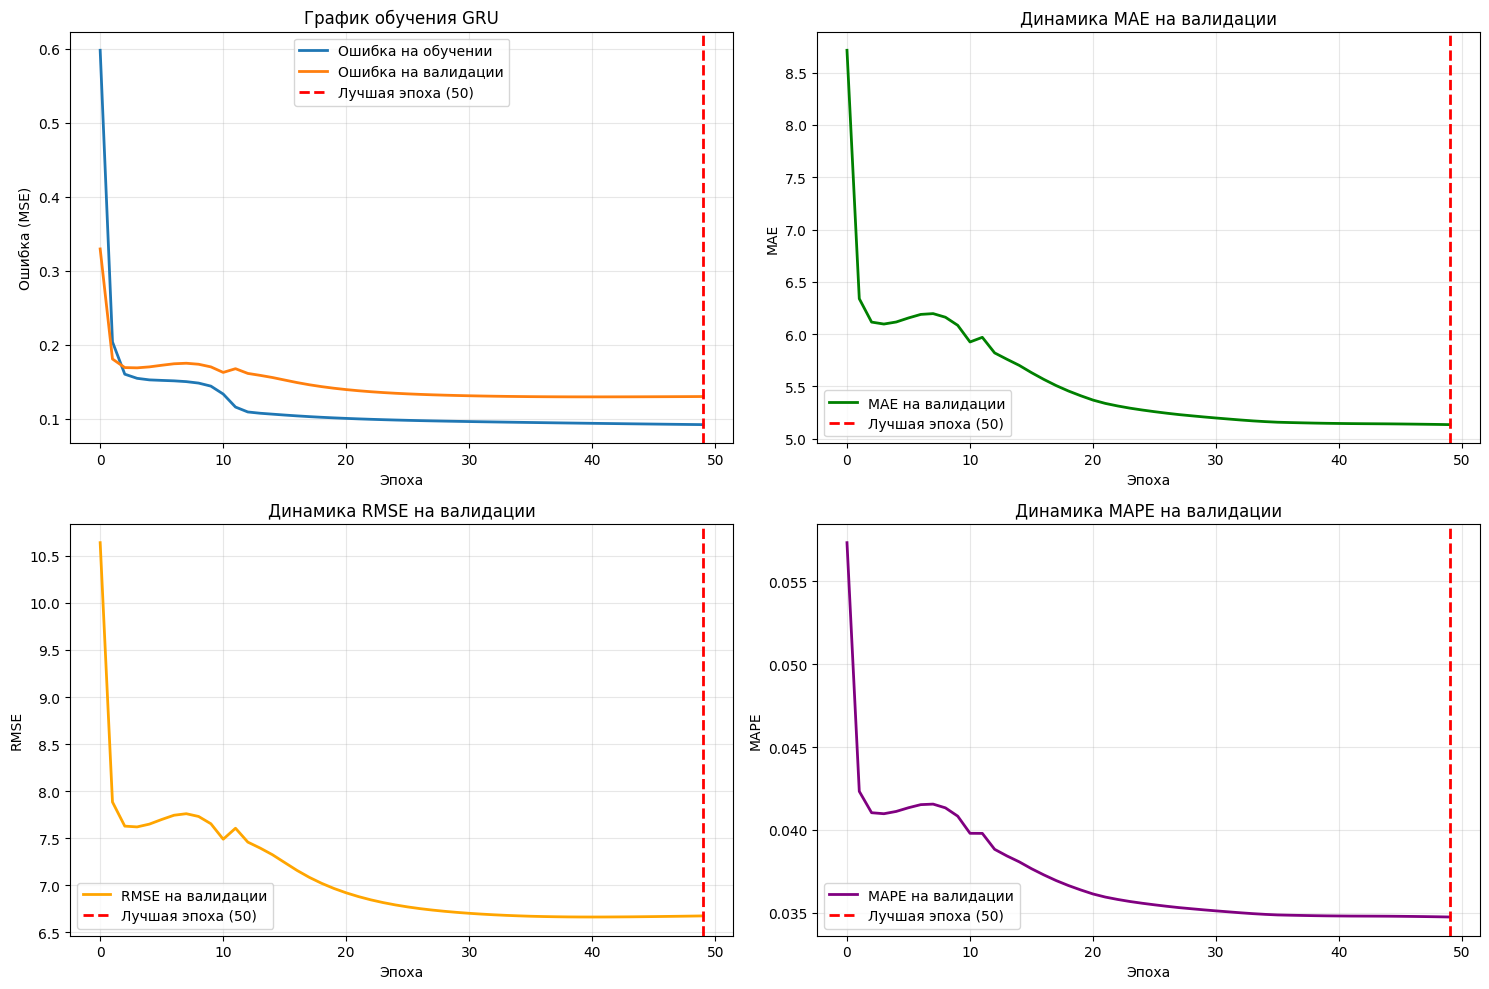

In [32]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Ошибка на обучении', linewidth=2)
plt.plot(val_losses, label='Ошибка на валидации', linewidth=2)
plt.axvline(x=best_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Лучшая эпоха ({best_epoch})')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка (MSE)')
plt.title('График обучения GRU')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(val_maes, label='MAE на валидации', linewidth=2, color='green')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Лучшая эпоха ({best_epoch})')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Динамика MAE на валидации')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(val_rmses, label='RMSE на валидации', linewidth=2, color='orange')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Лучшая эпоха ({best_epoch})')
plt.xlabel('Эпоха')
plt.ylabel('RMSE')
plt.title('Динамика RMSE на валидации')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(val_mapes, label='MAPE на валидации', linewidth=2, color='purple')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Лучшая эпоха ({best_epoch})')
plt.xlabel('Эпоха')
plt.ylabel('MAPE')
plt.title('Динамика MAPE на валидации')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

In [33]:
config = {
    "model_type": "GRU",
    "window_size": window_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "n_epochs": n_epochs,
    "best_epoch": best_epoch,
    "best_val_mae": float(best_val_mae),
    "best_val_rmse": float(best_val_rmse),
    "best_val_mape": float(best_val_mape),
    "test_mae": float(test_metrics['mae']),
    "test_rmse": float(test_metrics['rmse']),
    "test_mape": float(test_metrics['mape']),
    "scaler": "StandardScaler(target)",
    "seed": RANDOM_SEED,
    "device": str(device)
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)

In [34]:
with open("artifacts/runs.csv", "w", newline="", encoding='utf-8') as f:
    writer = csv.writer(f)

    writer.writerow([
        "experiment_id","task","dataset","seed","split_summary","window_size","horizon",
        "model_summary","features_summary","scaler","optimizer","lr","epochs_trained",
        "best_val_mae","best_val_rmse","best_val_mape",
        "test_mae","test_rmse","test_mape","notes"
    ])

    split_info = f"train={len(train)}/val={len(val)}/test={len(test)}"

    for i, row in experiments_res.iterrows():
        model_name = row['model']

        if "GRU" in model_name:
            continue

        exp_id = f"B{i+1}"

        if i == 0:
            features = "lag_1"
        elif i == 1:
            features = "rolling_mean_7"
        else:
            features = "lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, dayofweek, hour"

        scaler = "None" if i < 2 else "StandardScaler"

        writer.writerow([
            exp_id,
            "forecasting",
            "S12-hw-dataset",
            42,
            split_info,
            "",
            1,
            model_name,
            features,
            scaler,
            "", "", "",
            f"{row['MAE']:.6f}", f"{row['RMSE']:.6f}", f"{row['MAPE_%']:.6f}",
            "", "", "", "Baseline"
        ])

    split_info_r1 = f"train={len(train_dataset)}/val={len(val_dataset)}/test={len(test_dataset)}"

    writer.writerow([
        "R1", "forecasting", "S12-hw-dataset",
        42, split_info_r1, window_size, 1,
        f"GRU (window={window_size})", "target (windowed)", "StandardScaler", "Adam",
        learning_rate, n_epochs,
        f"{best_val_mae:.6f}", f"{best_val_rmse:.6f}", f"{best_val_mape:.6f}",
        f"{test_metrics['mae']:.6f}", f"{test_metrics['rmse']:.6f}", f"{test_metrics['mape']:.6f}",
        "Best model"
    ])